In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [2]:
from python.analysis import cross_section, Application, Master, Plots
from python.analysis.MaCh3FitOutput import MaCh3FitOutput
import numpy as np
import awkward as ak
import scipy.stats as stats


cross_section.PlotStyler()

In [3]:
config = "work/analysis_new_selection/analysis_config_new_selection.json"
args = Application.ApplicationArguments.ResolveConfig(Master.LoadConfiguration(config))
ais = {k : cross_section.LoadObject(v) for k, v in args.analysis_input.items() if "mc" in k}

In [4]:
postfit_results = MaCh3FitOutput("/home/bhuller/mach3_dune/MaCh3_DUNE/Test.root", args.process_definitions, args.energy_slices)

book = Plots.PlotBook("xs_extract", True, None)


pdf xs_extract.pdf has been opened


In [5]:
from matplotlib.patches import Rectangle

def HighlightCells(ax, mask):
    rows, cols = np.where(mask)

    for row, col in zip(rows, cols):
        ax.add_patch(
            Rectangle(
                (col - 0.5, row - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )
    return

def PlotMatrix(matrix : np.ndarray, highlight : np.ndarray = None, title : str = None):
    fig, ax = Plots.plt.subplots()

    im = ax.imshow(matrix)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("mean value")

    ticks = ["Overflow", 0, 1, 2, "Underflow"]
    Plots.plt.grid(False)
    Plots.plt.xticks(range(len(ticks)), ticks)
    Plots.plt.yticks(range(len(ticks)), ticks)
    Plots.plt.title(title)

    if highlight is not None:
        HighlightCells(ax, highlight)
    return

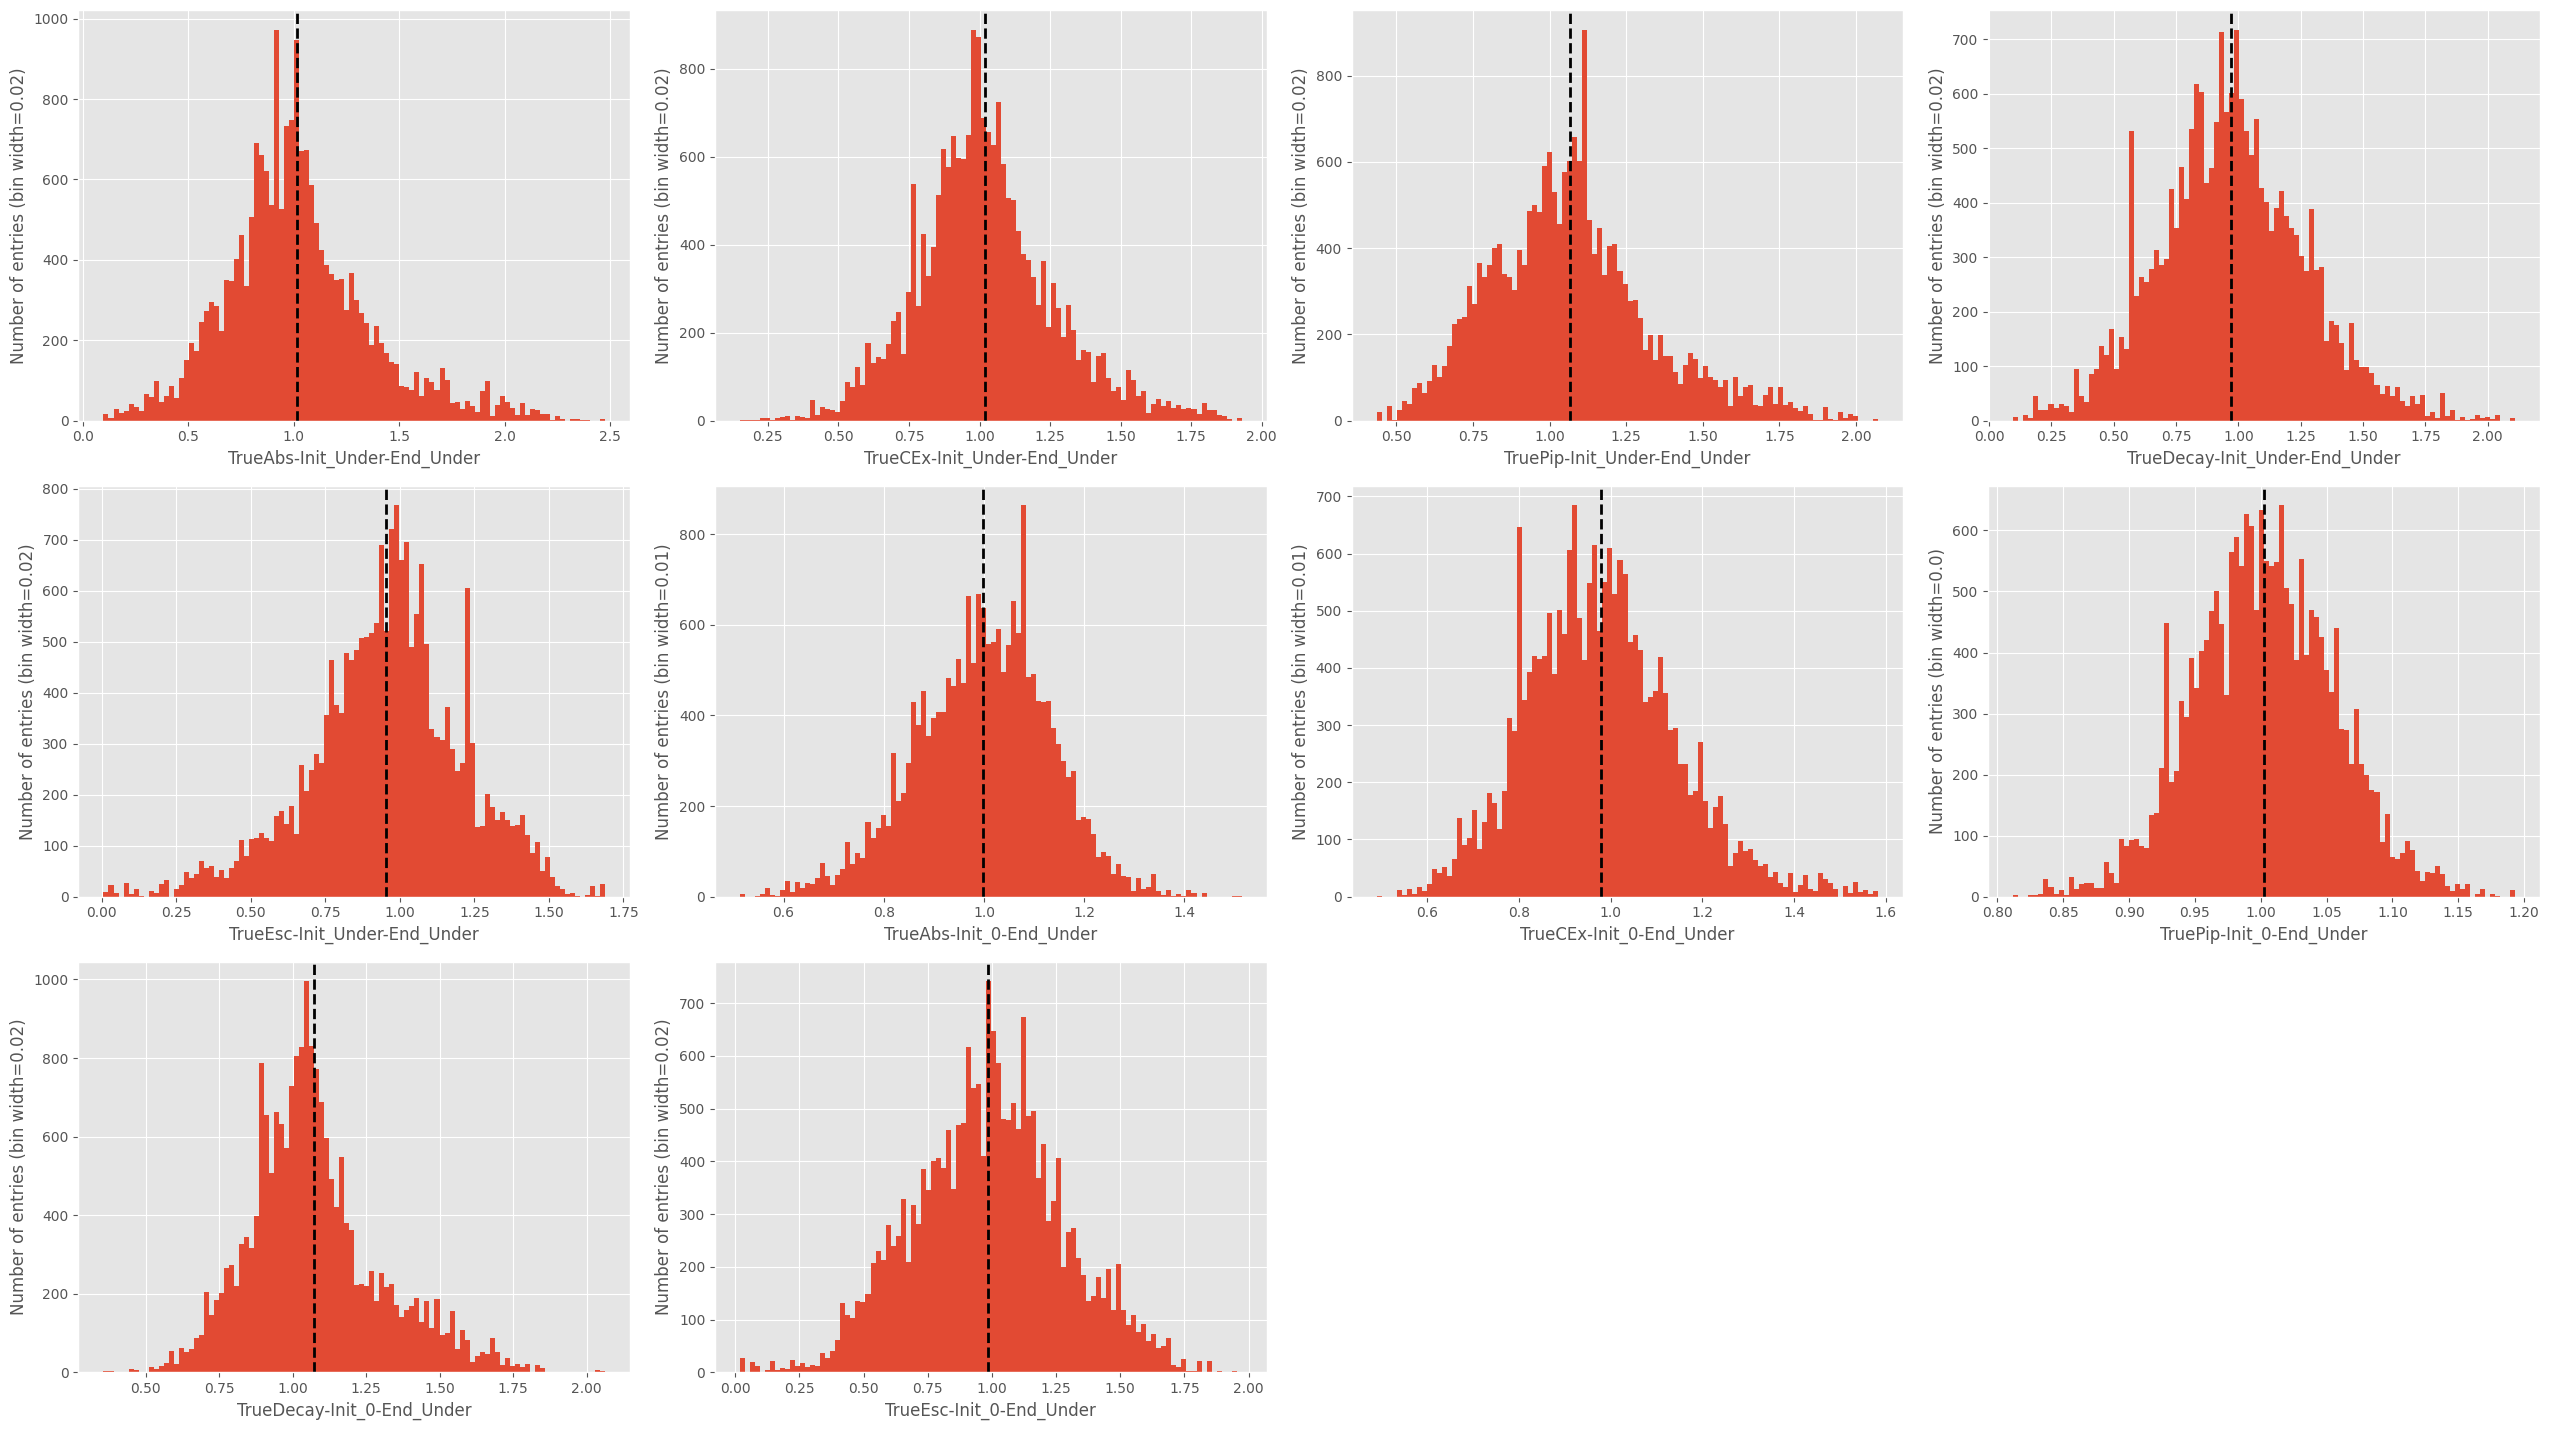

In [6]:
for i in Plots.MultiPlot(10):
    k, v = list(postfit_results.posteriors.items())[i]
    Plots.PlotHist(v, xlabel = k, newFigure=False)
    Plots.plt.axvline(np.mean(v), color = "k", linewidth=2, linestyle = "--")
book.Save()

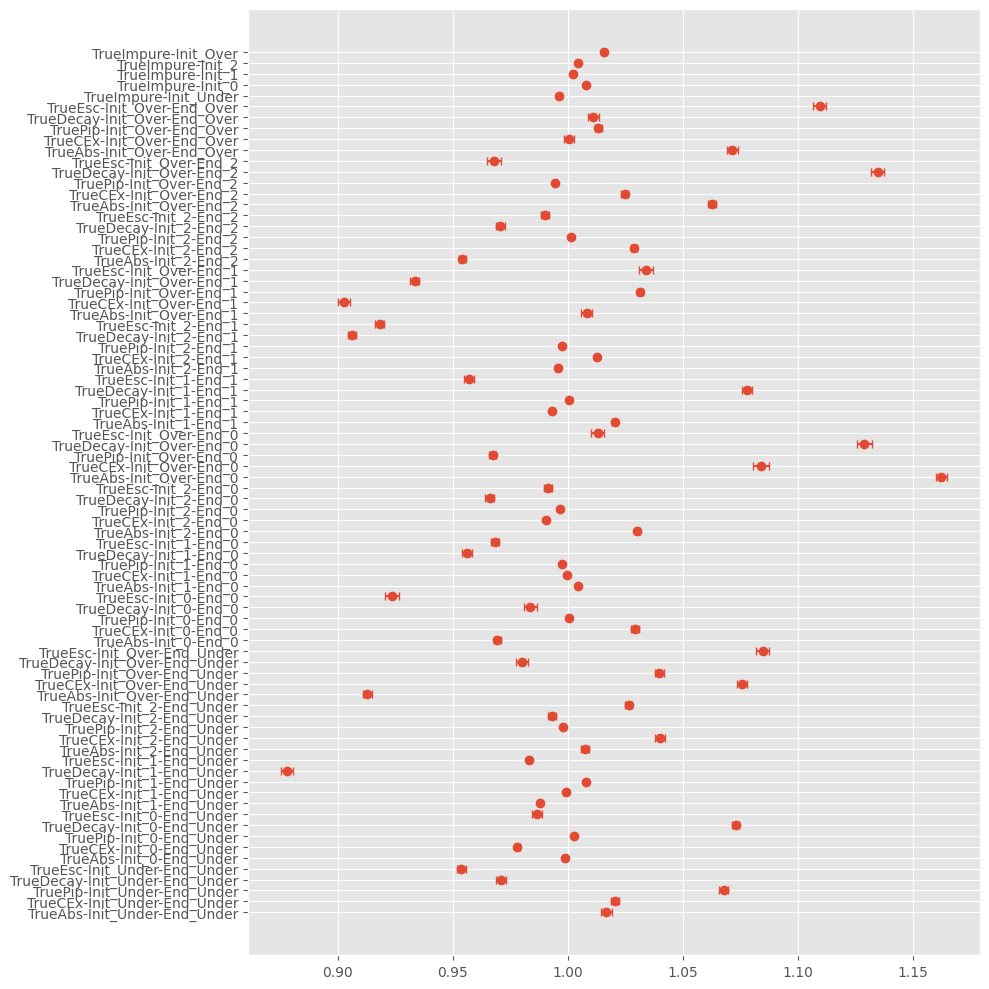

In [7]:
mean_params = {k : np.mean(v) for k, v in postfit_results.posteriors.items()}
stderr_params = {k : abs(stats.t.interval(0.68, len(v)-1, loc=np.mean(np.array(v)), scale=stats.sem(np.array(v)))[0] - np.mean(v)) for k, v in postfit_results.posteriors.items()}

Plots.plt.figure(figsize=[10, 10])
Plots.Plot(list(mean_params.values()), range(len(mean_params)), xerr=list(stderr_params.values()), newFigure=False, marker="o", linestyle="")
Plots.plt.yticks(range(len(mean_params)), list(mean_params.keys()), rotation=0)
Plots.plt.tight_layout()
book.Save()

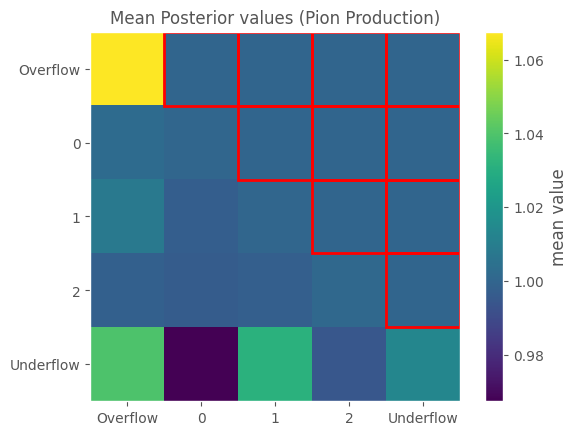

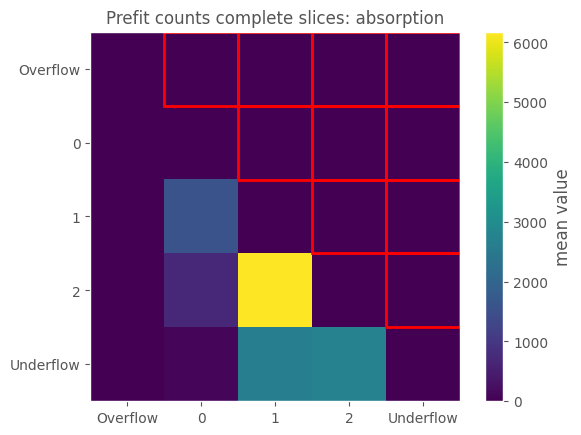

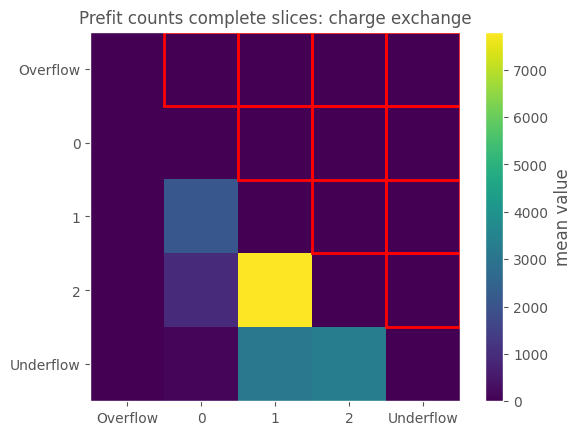

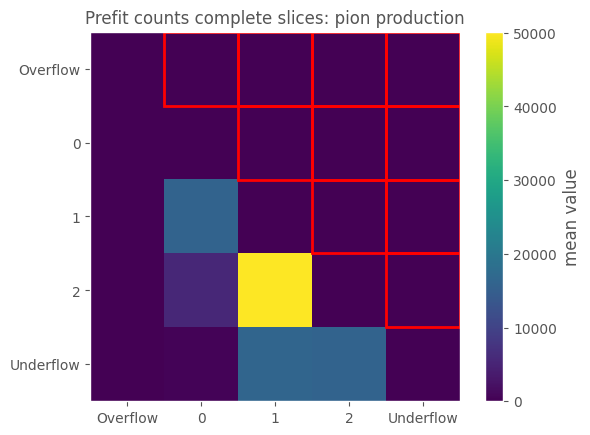

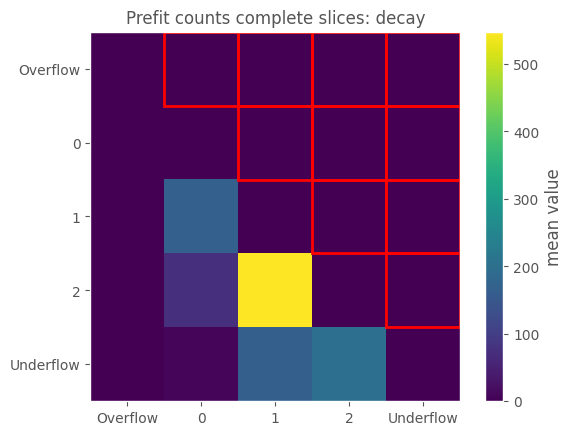

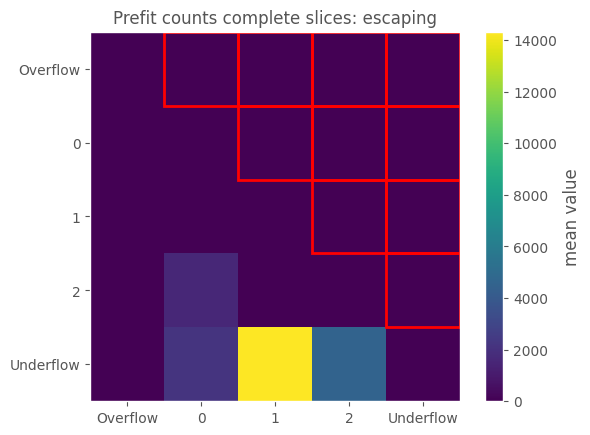

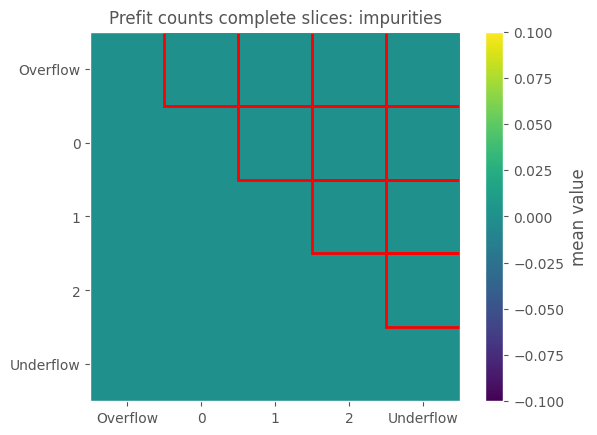

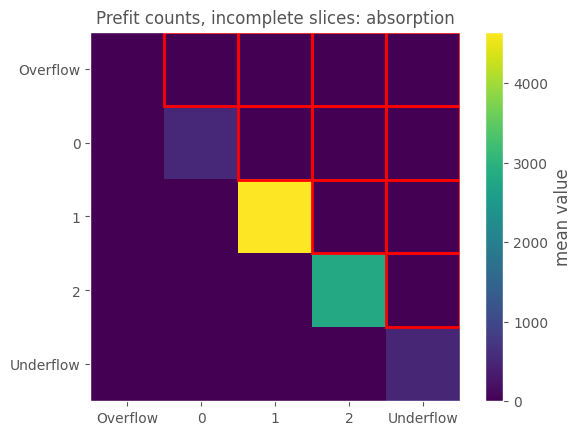

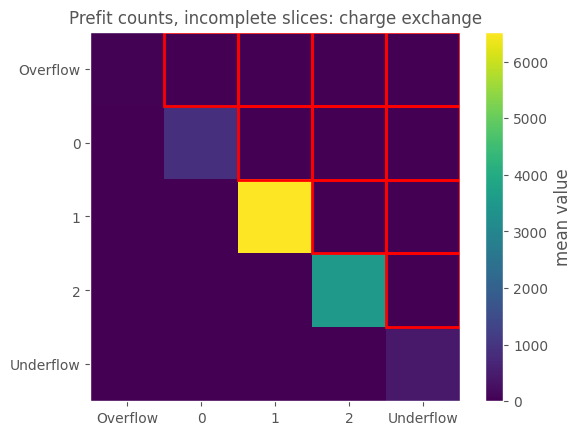

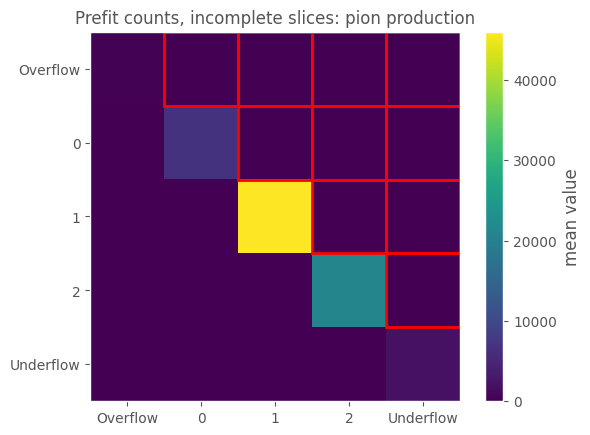

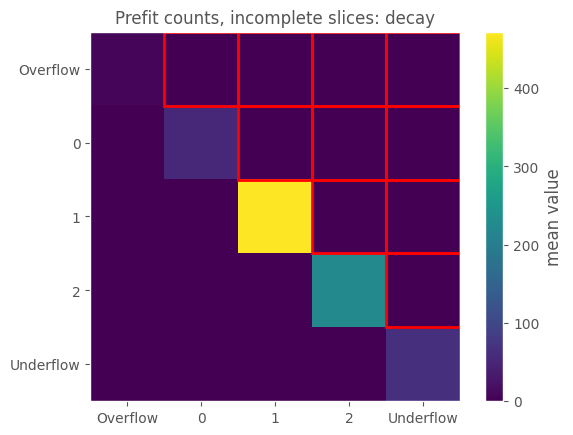

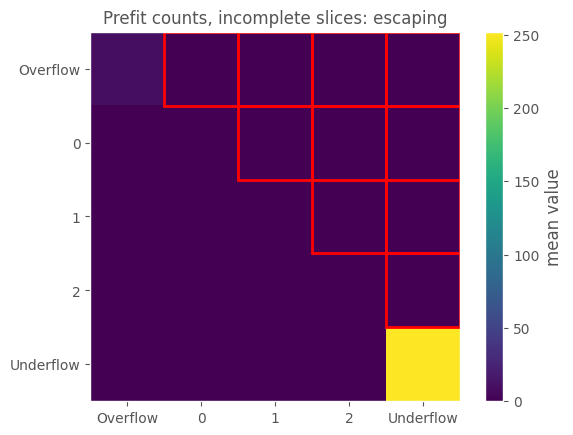

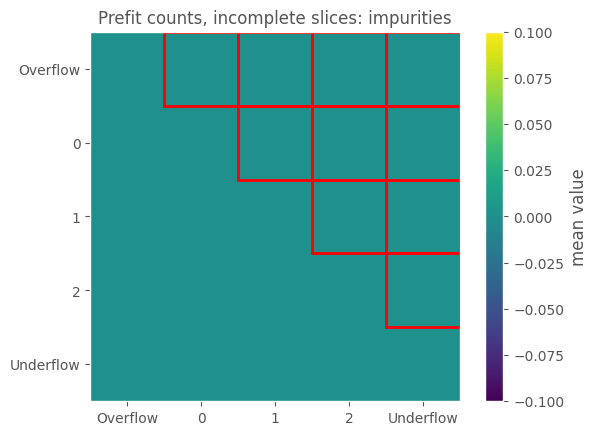

In [8]:
post_tensor = postfit_results.posterior_tensors()

prefit_counts_valid, prefit_counts_invalid = cross_section.EnergySlice.counting_experiment_tensor_process(ais["mc_cheated"].KE_init_true, ais["mc_cheated"].KE_end_true, args.energy_slices, ais["mc_cheated"].get_outside_mask(args.fiducial_volume), ais["mc_cheated"].exclusive_process, None)
postfit_counts_valid, postfit_counts_invalid = cross_section.EnergySlice.counting_experiment_tensor_process(ais["mc_cheated"].KE_init_true, ais["mc_cheated"].KE_end_true, args.energy_slices, ais["mc_cheated"].get_outside_mask(args.fiducial_volume), ais["mc_cheated"].exclusive_process, post_tensor)

nominal = ak.all(post_tensor["pion_production"] == 1, axis=-1)
PlotMatrix(ak.mean(post_tensor["pion_production"], axis=-1), nominal, "Mean Posterior values (Pion Production)")
book.Save()

for k, v in prefit_counts_valid.items():
    PlotMatrix(v, nominal, title = f"Prefit counts complete slices: {cross_section.remove_(k)}")
    book.Save()

for k, v in prefit_counts_invalid.items():
    PlotMatrix(v, nominal, title = f"Prefit counts, incomplete slices: {cross_section.remove_(k)}")
    book.Save()

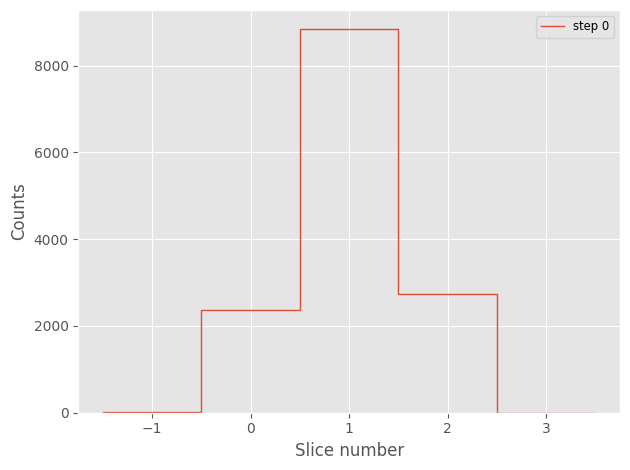

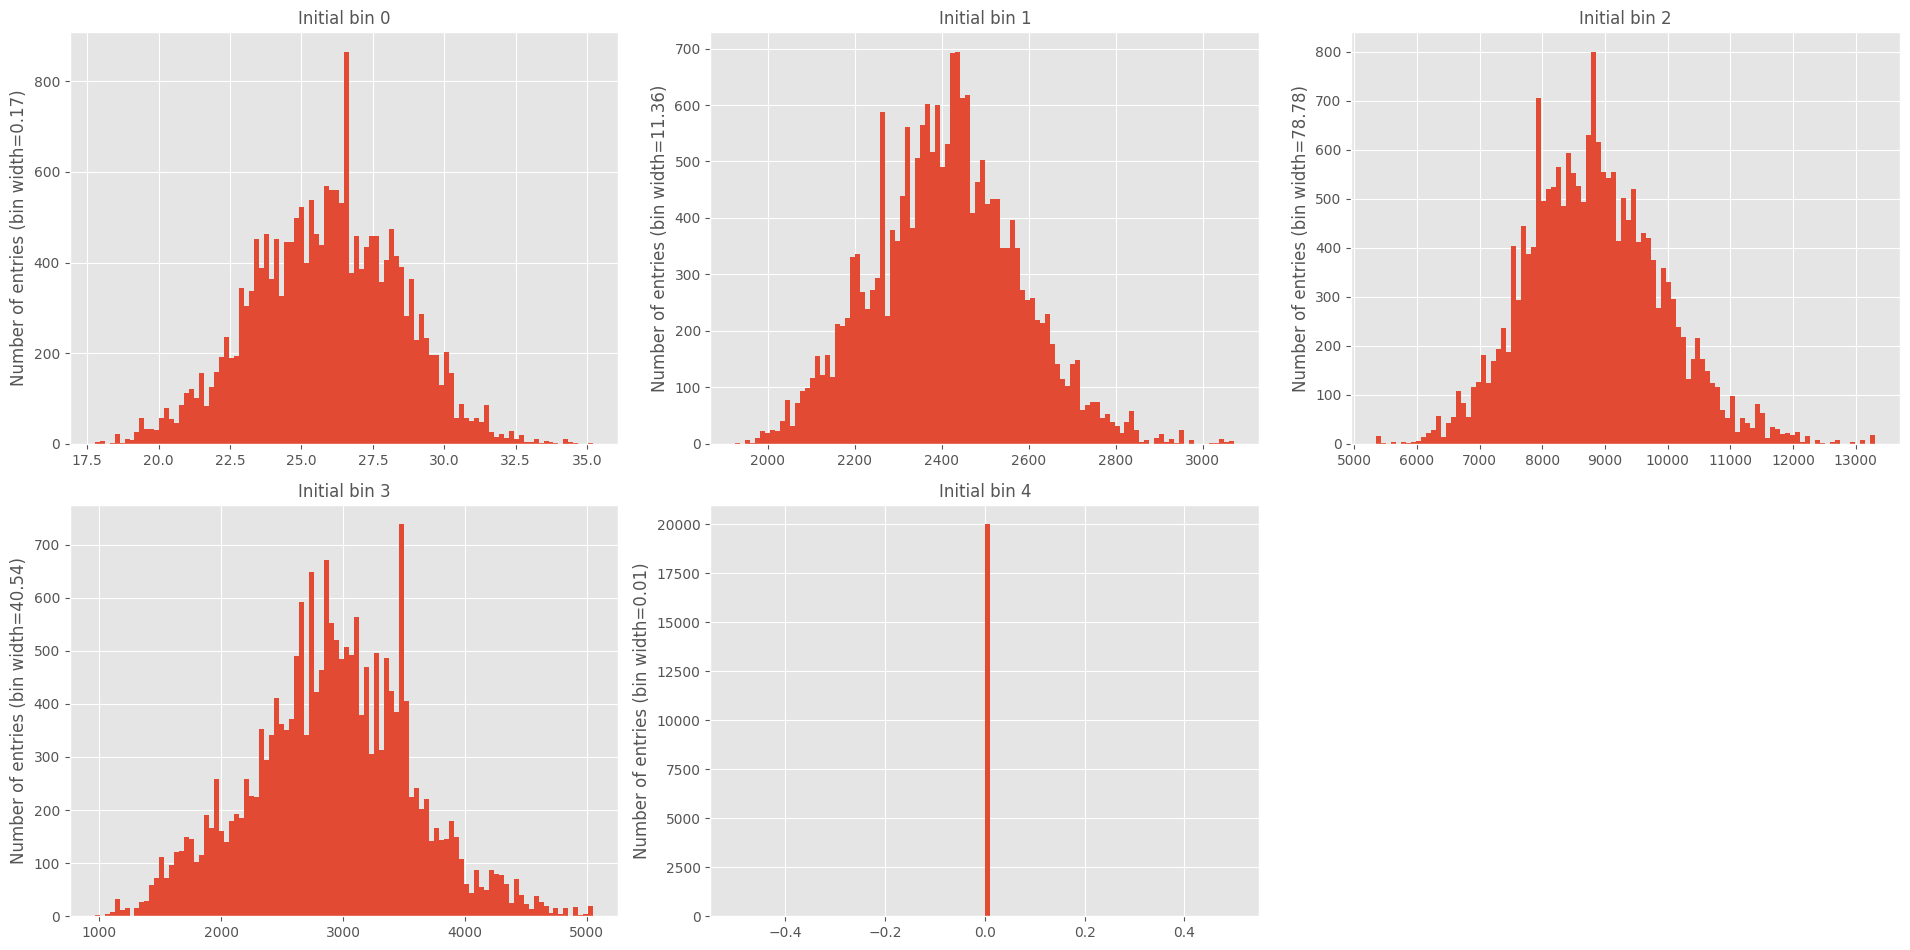

In [9]:
n_init = np.sum(postfit_counts_valid["absorption"], 0)
n_init[:, 0]
Plots.Plot(args.energy_slices.num_all, n_init[:, 0], label=f"step {0}", xlabel="Slice number", ylabel = "Counts", style="step", color = "C0")

for i, n in Plots.IterMultiPlot(n_init):
    Plots.PlotHist(n, newFigure=False, title=f"Initial bin {i}")
book.Save()

In [10]:
def calculate_interaction_tensor(counts : dict[np.ndarray]) -> np.ndarray:
    interaction_tensor = None
    for k, v in counts.items():
        if k in ["impurities", "decay"]: continue # background channel
        if interaction_tensor is None:
            interaction_tensor = v
        else:
            interaction_tensor = interaction_tensor + v
    return interaction_tensor

prefit_interaction_tensor_valid = calculate_interaction_tensor(prefit_counts_valid)
postfit_interaction_tensor_valid = calculate_interaction_tensor(postfit_counts_valid)

# required for the exclusive cross section calculation.
prefit_interaction_tensor_all = prefit_interaction_tensor_valid + calculate_interaction_tensor(prefit_counts_invalid)
postfit_interaction_tensor_all = postfit_interaction_tensor_valid + calculate_interaction_tensor(postfit_counts_invalid)

In [11]:
prefit_incident_counts = cross_section.EnergySlice.incident(np.sum(prefit_interaction_tensor_valid, 0), np.sum(prefit_interaction_tensor_valid, 1), 0)
postfit_incident_counts = cross_section.EnergySlice.incident(np.sum(postfit_interaction_tensor_valid, 0), np.sum(postfit_interaction_tensor_valid, 1), 0)

In [12]:
postfit_end = np.sum(postfit_interaction_tensor_valid, 1)
dEdX = cross_section.BetheBloch.mean_dEdX(args.energy_slices.pos - args.energy_slices.width/2, cross_section.Particle.from_pdgid(211))

total_xs_tensor = cross_section.EnergySlice.total_cross_section(postfit_incident_counts[1:-1], postfit_end[1:-1], dEdX, args.energy_slices.width) # ignore the stat error propagation


In [13]:
postfit_end_all = np.sum(postfit_interaction_tensor_valid, 1)
postfit_int_all = {k : np.sum(v + postfit_counts_invalid[k], 1) for k, v in postfit_counts_valid.items()}

exclusive_xs_tensors = {}
for k, v in postfit_int_all.items():
    if k not in ["impurities", "decay", "escaping"]:
        exclusive_xs_tensors[k] = cross_section.EnergySlice.exclusive_cross_section(postfit_incident_counts[1:-1], postfit_end[1:-1], postfit_end_all[1:-1], v[1:-1], dEdX, args.energy_slices.width)

In [14]:
n_initial, n_end, n_incident = cross_section.EnergySlice.counting_experiment(ais["mc_cheated"].KE_init_true, ais["mc_cheated"].KE_end_true, args.energy_slices, ais["mc_cheated"].get_outside_mask(args.fiducial_volume))
print(f"{n_initial=}")
print(f"{n_end=}")
print(f"{n_incident=}")

total_xs_prefit = cross_section.EnergySlice.total_cross_section(n_incident[1:-1], n_end[1:-1], dEdX, args.energy_slices.width)

n_initial=array([   301,  31620, 101288,  26745,      3])
n_end=array([    0,   232, 20007, 73527, 66191])
n_incident=array([     0,    301,  31689, 112970,  66188])


In [15]:
exclusive_xs_prefit = {}
for k, v in ais["mc_cheated"].exclusive_process.items():
    if k not in ["impurities", "decay", "escaping"]:
        n_end_all, n_int_all = cross_section.EnergySlice.counting_experiment_exclusive(args.energy_slices, ais["mc_cheated"].KE_end_true, v, ais["mc_cheated"].get_outside_mask(args.fiducial_volume))
        exclusive_xs_prefit[k] = cross_section.EnergySlice.exclusive_cross_section(n_incident[1:-1], n_end[1:-1], n_end_all[1:-1], n_int_all[1:-1], dEdX, args.energy_slices.width)

In [16]:
def PlotCrossSectionPosteriorRange(xs_tensor, xs_prefit, plot_name, energy_slices, geant_xs=None):
    xs_central, xs_err = xs_tensor

    geant_xs = cross_section.GeantCrossSections(energy_range=[1000, 2200])

    max_xs = ak.max(xs_central, 1)
    max_xs_err = ak.ravel(
        ak.Array(xs_err[ak.local_index(xs_err, axis=1) == ak.argmax(xs_central, 1, keepdims=True)])
    )
    min_xs = ak.min(xs_central, 1)
    min_xs_err = ak.ravel(
        ak.Array(xs_err[ak.local_index(xs_err, axis=1) == ak.argmin(xs_central, 1, keepdims=True)])
    )

    x = energy_slices.pos - energy_slices.width / 2

    Plots.plt.figure()
    geant_xs.Plot(plot_name, simplified_pion_production=True)

    series = [
        ("prefit", xs_prefit[0], xs_prefit[1], "o"),
        ("minimum", min_xs, min_xs_err, "o"),
        ("maximum", max_xs, max_xs_err, "x"),
    ]

    for label, y, yerr, marker in series:
        Plots.Plot(
            x,
            y,
            xerr=energy_slices.width / 2,
            yerr=yerr,
            newFigure=False,
            marker=marker,
            label=label,
        )

    Plots.plt.legend()
    Plots.plt.ylim(0, 800)
    return min_xs, max_xs, min_xs_err, max_xs_err

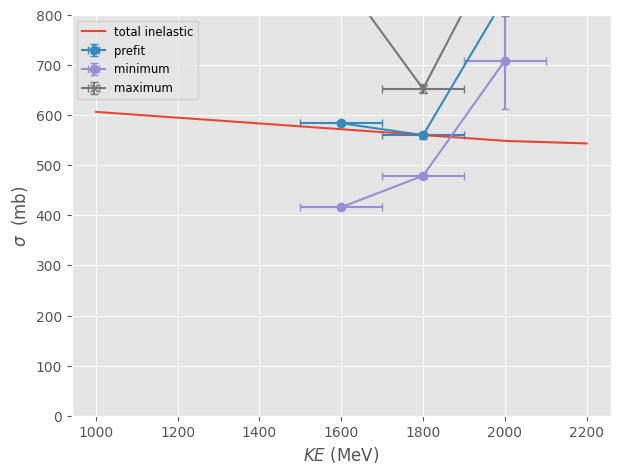

In [17]:
cross_sections = cross_section.GeantCrossSections(energy_range = [1000, 2200])

PlotCrossSectionPosteriorRange(
    total_xs_tensor,
    total_xs_prefit,
    "total_inelastic",
    args.energy_slices,
    cross_sections,
)

book.Save()

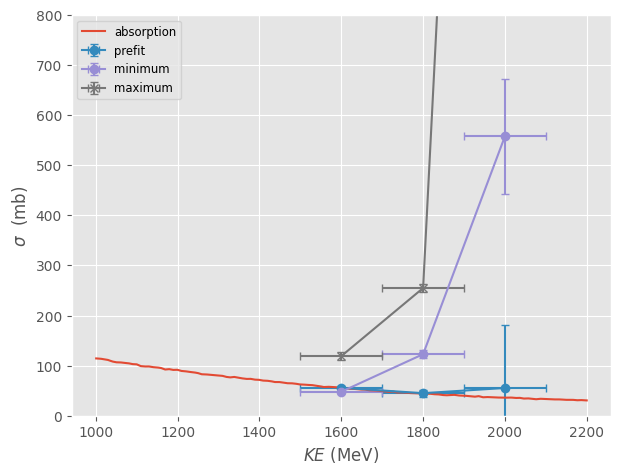

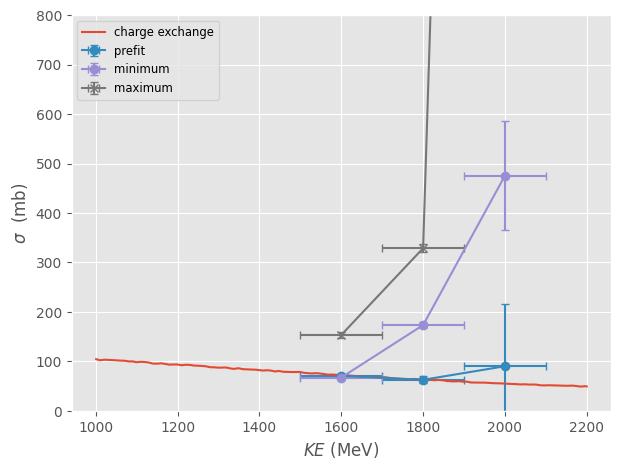

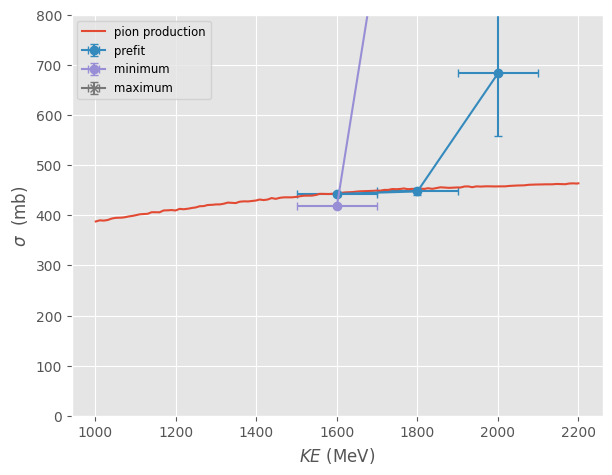

In [18]:
for k, v in exclusive_xs_tensors.items():
    PlotCrossSectionPosteriorRange(
    v,
    exclusive_xs_prefit[k],
    k,
    args.energy_slices,
    cross_sections,
    )
    book.Save()

Means and confidence intervals

In [19]:
def PlotCrossSectionCL(xs_tensor, xs_prefit, plot_name, energy_slices, confidence_level : float = 0.68, geant_xs=None):
    xs_central, xs_err = xs_tensor # neglect the stat error propagation.

    mean_xs = np.mean(xs_central, axis=1)
    ci = stats.t.interval(confidence_level, df=len(xs_central)-1, loc=mean_xs, scale=np.std(xs_central, ddof=1) / np.sqrt(len(xs_central)))

    geant_xs = cross_section.GeantCrossSections(energy_range=[1000, 2200])

    x = energy_slices.pos - energy_slices.width / 2

    Plots.plt.figure()
    geant_xs.Plot(plot_name, simplified_pion_production=True)

    series = [
        ("prefit", xs_prefit[0], xs_prefit[1], "o"),
        ("postfit", mean_xs, np.abs(ci), "o"),
    ]

    for label, y, yerr, marker in series:
        Plots.Plot(
            x,
            y,
            xerr=energy_slices.width / 2,
            yerr=yerr,
            newFigure=False,
            marker=marker,
            label=label,
        )

    Plots.plt.legend()
    return

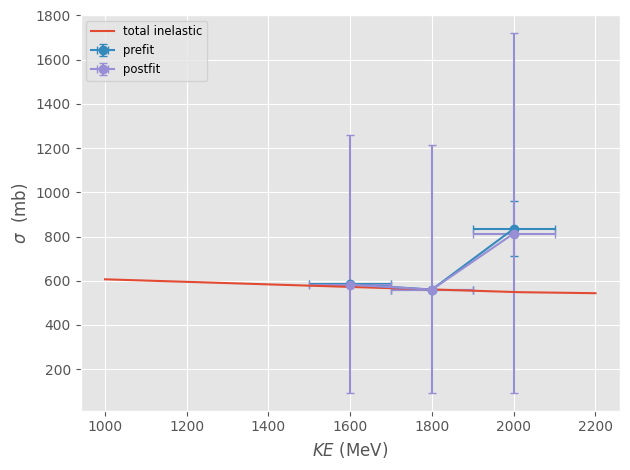

In [20]:
PlotCrossSectionCL(total_xs_tensor, total_xs_prefit, "total_inelastic", args.energy_slices, 0.68)
book.Save()

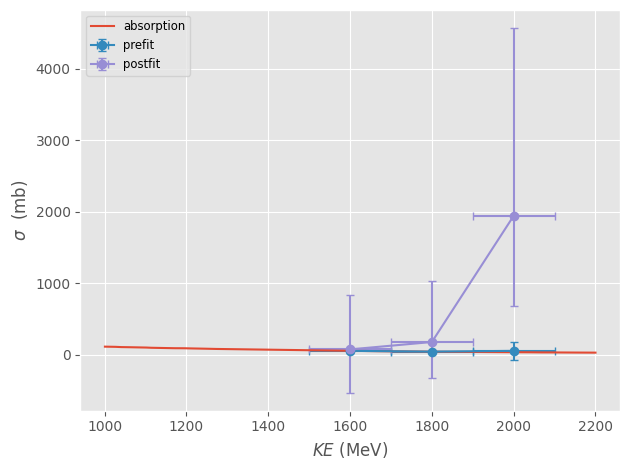

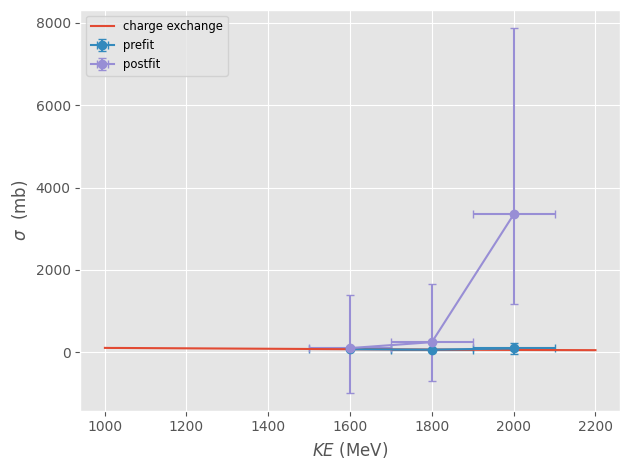

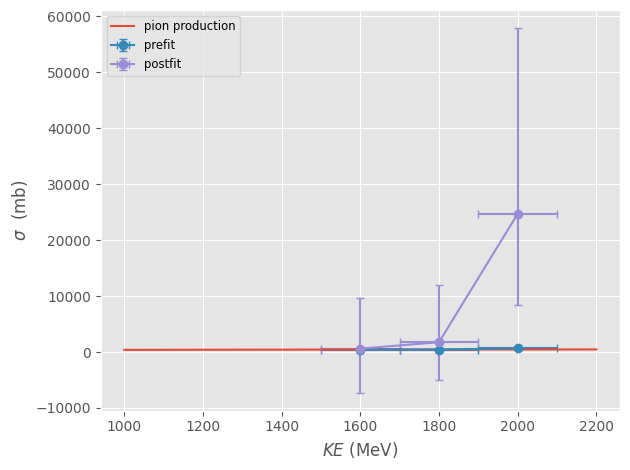

In [21]:
for k, v in exclusive_xs_tensors.items():
    PlotCrossSectionCL(
    v,
    exclusive_xs_prefit[k],
    k,
    args.energy_slices,
    )
    book.Save()

In [22]:
book.close()

pdf xs_extract.pdf has been closed
